# Multimodal Integration Notebook v1
### Armenian Deposit Dollarization Forecasting
### Student — Zvarth Aleksanyan

**Purpose:** Integrate NLP features from CBA corpus into the structured forecasting pipeline and test whether central bank communication adds statistically significant forecasting value beyond structured macroeconomic variables.

**Inputs:**
- `modelling_results.xlsx` — structured model predictions from Notebook 1
- `nlp_features.csv` — CBA document scores from Notebook 2
- `Database_CBA_Rates and indicators.xlsx` — raw data (fallback path)

**Research question:** Does unstructured CBA communication data improve forecast accuracy beyond structured macro variables? Tested via Diebold-Mariano.

**Models extended:** LASSO and Elastic Net only. HAR stays pure (lag-only by design).

In [61]:
# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams.update({
    'figure.facecolor':'#1e1e1e','axes.facecolor':'#2d2d2d',
    'axes.edgecolor':'#555','text.color':'white',
    'axes.labelcolor':'white','xtick.color':'white','ytick.color':'white',
    'legend.facecolor':'#3d3d3d','grid.color':'#444','grid.alpha':0.4
})
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from scipy import stats as scipy_stats
import os

np.random.seed(42)
print('Imports OK')

Imports OK


In [62]:
# ── 1. PATHS ──────────────────────────────────────────────────────────────────
BASE = r'Analysis'

RESULTS_PATH = r'Analysis\Outputs\modelling_results.xlsx'
NLP_PATH     = r'Analysis\Outputs\nlp_features.csv'
DB_PATH      = r'Analysis\Data\Structured\Database_CBA_Rates and indicators.xlsx'
OUTPUT_DIR   = r'Analysis\Outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET   = 'd2_deposit_dollarization'
NLP_COLS = ['ir_cba_tone', 'ir_dollarization_intensity', 'ir_policy_uncertainty',
            'fsr_cba_tone', 'fsr_dollarization_intensity', 'fsr_policy_uncertainty']

print('Paths configured.')

Paths configured.


## Cell 2 — Load Structured Predictions

Primary path: load from `modelling_results.xlsx` (All_Predictions sheet). This keeps Notebook 3 independent of raw data processing.

Fallback: if the file is not found, rebuild the model matrix from `Database.xlsx` directly.

In [63]:
# ── 2. LOAD STRUCTURED PREDICTIONS ───────────────────────────────────────────

if os.path.exists(RESULTS_PATH):
    print('Loading from modelling_results.xlsx ...')
    df_preds = pd.read_excel(RESULTS_PATH, sheet_name='All_Predictions')
    df_preds['Date'] = pd.to_datetime(df_preds['Date'])
    df_preds = df_preds.sort_values('Date').reset_index(drop=True)
    print(f'  Loaded: {df_preds.shape}  ({df_preds.Date.min().date()} → {df_preds.Date.max().date()})')
    print(f'  Columns: {df_preds.columns.tolist()}')
    USE_PRECOMPUTED = True

else:
    print('modelling_results.xlsx not found — rebuilding from Database.xlsx')
    df_raw = pd.read_excel(DB_PATH)
    df_raw.columns = (df_raw.columns.str.strip().str.lower()
                      .str.replace(' ','_').str.replace(r'[^a-z0-9_]','',regex=True))
    date_col = [c for c in df_raw.columns if 'date' in c][0]
    df_raw['Date'] = pd.to_datetime(df_raw[date_col])
    df_raw = df_raw.sort_values('Date').reset_index(drop=True)
    df_preds = df_raw[['Date', TARGET]].copy()
    USE_PRECOMPUTED = False
    print(f'  Loaded raw data: {df_raw.shape}')

Loading from modelling_results.xlsx ...
  Loaded: (153, 10)  (2013-01-31 → 2025-09-09)
  Columns: ['Date', 'd2_deposit_dollarization', 'HAR', 'Elastic_Net', 'LASSO', 'Ridge', 'VAR', 'ARDL_ECM', 'RW_Naive', 'RM_Naive']


## Cell 3 — Load and Align NLP Features

The `nlp_features.csv` contains per-document scores. Here we:
1. Separate IR and FSR documents
2. Aggregate to monthly frequency
3. Forward-fill with limit=4 months
4. Merge onto the structured date range

In [64]:
# ── 3. LOAD AND ALIGN NLP FEATURES ───────────────────────────────────────────
df_nlp_raw = pd.read_csv(NLP_PATH)
df_nlp_raw['Date'] = pd.to_datetime(df_nlp_raw['date_key'])
df_nlp_raw = df_nlp_raw.sort_values('Date').reset_index(drop=True)

print(f'NLP documents loaded: {len(df_nlp_raw)} ({df_nlp_raw.doc_type.value_counts().to_dict()})')

SCORE_COLS = ['cba_tone', 'dollarization_intensity', 'policy_uncertainty']

# Separate IR and FSR, aggregate per date
df_ir  = (df_nlp_raw[df_nlp_raw['doc_type']=='IR']
          .groupby('Date')[SCORE_COLS].mean().reset_index())
df_fsr = (df_nlp_raw[df_nlp_raw['doc_type']=='FSR']
          .groupby('Date')[SCORE_COLS].mean().reset_index())

df_ir.columns  = ['Date'] + [f'ir_{c}'  for c in SCORE_COLS]
df_fsr.columns = ['Date'] + [f'fsr_{c}' for c in SCORE_COLS]

# Build monthly grid covering structured data range
date_min = df_preds['Date'].min().replace(day=1)
date_max = df_preds['Date'].max().replace(day=1)
date_range  = pd.date_range(start=date_min, end=date_max, freq='MS')
df_monthly  = pd.DataFrame({'Date': date_range})

df_monthly = df_monthly.merge(df_ir,  on='Date', how='left')
df_monthly = df_monthly.merge(df_fsr, on='Date', how='left')

ir_cols  = [c for c in df_monthly.columns if c.startswith('ir_')]
fsr_cols = [c for c in df_monthly.columns if c.startswith('fsr_')]
all_nlp  = ir_cols + fsr_cols

df_monthly[ir_cols]  = df_monthly[ir_cols].ffill(limit=4)
df_monthly[fsr_cols] = df_monthly[fsr_cols].ffill(limit=4)

print('\nNLP feature coverage after forward-fill:')
for col in all_nlp:
    n   = df_monthly[col].notna().sum()
    pct = n / len(df_monthly) * 100
    print(f'  {col:<35} {n:3d}/{len(df_monthly)} ({pct:.0f}%)')

NLP documents loaded: 69 ({'IR': 56, 'FSR': 13})

NLP feature coverage after forward-fill:
  ir_cba_tone                         152/153 (99%)
  ir_dollarization_intensity          152/153 (99%)
  ir_policy_uncertainty               152/153 (99%)
  fsr_cba_tone                         65/153 (42%)
  fsr_dollarization_intensity          65/153 (42%)
  fsr_policy_uncertainty               65/153 (42%)


In [65]:
# ── 4. MERGE STRUCTURED + NLP ─────────────────────────────────────────────────
# Normalise dates to month-start before merging
df_preds['Date_m']   = df_preds['Date'].dt.to_period('M').dt.to_timestamp()
df_monthly['Date_m'] = df_monthly['Date'].dt.to_period('M').dt.to_timestamp()

df_merged = df_preds.merge(df_monthly[['Date_m'] + all_nlp],
                            on='Date_m', how='left')
df_merged = df_merged.drop(columns=['Date_m'])
df_merged = df_merged.sort_values('Date').reset_index(drop=True)

print(f'Merged dataset: {df_merged.shape}')
print(f'Date range: {df_merged.Date.min().date()} → {df_merged.Date.max().date()}')
print(f'\nMissing NLP values in merged dataset:')
for col in all_nlp:
    print(f'  {col:<35} {df_merged[col].isna().sum()} missing')

Merged dataset: (153, 16)
Date range: 2013-01-31 → 2025-09-09

Missing NLP values in merged dataset:
  ir_cba_tone                         1 missing
  ir_dollarization_intensity          1 missing
  ir_policy_uncertainty               1 missing
  fsr_cba_tone                        88 missing
  fsr_dollarization_intensity         88 missing
  fsr_policy_uncertainty              88 missing


## Cell 5 — Build Multimodal Model Matrix

This cell reconstructs the feature matrix using the same `LASSO_VARS` from Notebook 1, then appends the NLP features. The structured variable list must match Notebook 1 exactly.

In [66]:
# ── 5. BUILD MULTIMODAL MODEL MATRIX ─────────────────────────────────────────
df_raw = pd.read_excel(DB_PATH)
df_raw.columns = (df_raw.columns.str.strip().str.lower()
                  .str.replace(' ','_').str.replace(r'[^a-z0-9_]','',regex=True))
date_col = [c for c in df_raw.columns if 'date' in c][0]
df_raw['Date'] = pd.to_datetime(df_raw[date_col])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

df = df_raw.copy()

# Feature engineering — identical to Notebook 1
df['deposit_rate_diff']  = df['amd_deposit_rate'] - df['fx_deposit_rate']
df['lending_rate_diff']  = df['amd_lending_rate'] - df['fx_lending_rate']
df['usd_return']         = np.log(df['usd_amd']).diff()
df['usd_volatility_6m']  = df['usd_return'].rolling(6, min_periods=4).std()
df['rub_return']         = np.log(df['rub_amd']).diff()
df['rub_volatility_6m']  = df['rub_return'].rolling(6, min_periods=4).std()
df['gir_growth']         = np.log(df['gir']).diff()
df['neer_return']        = np.log(df['neer']).diff()
df['dol_lag1']           = df[TARGET].shift(1)
df['dol_lag3']           = df[TARGET].shift(1).rolling(3).mean()
df['dol_lag12']          = df[TARGET].shift(1).rolling(12).mean()
df['post_2022']          = (df['Date'] >= '2022-03-01').astype(int)
df['post_2020']          = (df['Date'] >= '2020-03-01').astype(int)
df['reer_x_break']       = df['reer'] * df['post_2022']
df['usd_ret_x_break']    = df['usd_return'] * df['post_2022']

LASSO_VARS = [
    'reer', 'amd_lending_rate', 'loans_fx_residents', 'remittances',
    'deposit_rate_diff', 'usd_volatility_6m', 'policy_rate',
    'usd_return', 'inflation', 'fx_lending_rate',
    'rub_return', 'rub_volatility_6m', 'gir_growth', 'neer_return',
    'eai_yoy', 'dol_lag1', 'dol_lag3', 'dol_lag12',
    'post_2022', 'reer_x_break', 'usd_ret_x_break', 'post_2020',
]
LASSO_VARS = [v for v in LASSO_VARS if v in df.columns]

# ── KEY FIX: align dates using year-month period ───────────────────────────────
# Convert both sides to period before merging to avoid end-of-month mismatch
df['ym'] = df['Date'].dt.to_period('M')
df_monthly['ym'] = df_monthly['Date_m'].dt.to_period('M')

df = df.merge(df_monthly[['ym'] + all_nlp], on='ym', how='left')
df = df.drop(columns=['ym'])

LASSO_VARS_MM = LASSO_VARS + all_nlp

# ── Structured model matrix ────────────────────────────────────────────────────
df_struct = df[['Date', TARGET] + LASSO_VARS].dropna().reset_index(drop=True)
X_s = df_struct[LASSO_VARS].values
y_s = df_struct[TARGET].values

# ── Multimodal model matrix ────────────────────────────────────────────────────
# Fill remaining NLP NaNs with 0 before dropna so we don't lose structured rows
df_mm_build = df[['Date', TARGET] + LASSO_VARS_MM].copy()
df_mm_build[all_nlp] = df_mm_build[all_nlp].fillna(0)
df_mm = df_mm_build.dropna().reset_index(drop=True)
X_mm = df_mm[LASSO_VARS_MM].values
y_mm = df_mm[TARGET].values

tscv = TimeSeriesSplit(n_splits=5, test_size=12)

print(f'Structured matrix:  {X_s.shape}  ({df_struct.Date.min().date()} → {df_struct.Date.max().date()})')
print(f'Multimodal matrix:  {X_mm.shape}  ({df_mm.Date.min().date()} → {df_mm.Date.max().date()})')
print(f'Structured vars: {len(LASSO_VARS)}')
print(f'Multimodal vars: {len(LASSO_VARS_MM)}')

# Verify alignment — both should have same length now
print(f'\nLength match: {len(y_s) == len(y_mm)} (both should be {len(y_s)})')

Structured matrix:  (153, 22)  (2013-01-31 → 2025-09-09)
Multimodal matrix:  (153, 28)  (2013-01-31 → 2025-09-09)
Structured vars: 22
Multimodal vars: 28

Length match: True (both should be 153)


## Cell 6 — Helper Functions

In [67]:
# ── 6. HELPER FUNCTIONS ───────────────────────────────────────────────────────

def oos_metrics(y_true, y_pred, name):
    mask = ~np.isnan(y_pred)
    if mask.sum() < 5:
        return {'Model':name,'RMSE':np.nan,'MAE':np.nan,'R²':np.nan,
                'MAPE (%)':np.nan,'Dir. Accuracy (%)':np.nan}
    yt, yp = y_true[mask], y_pred[mask]
    return {
        'Model':             name,
        'RMSE':              np.sqrt(mean_squared_error(yt, yp)),
        'MAE':               mean_absolute_error(yt, yp),
        'R²':                r2_score(yt, yp),
        'MAPE (%)':          np.mean(np.abs((yt-yp)/(np.abs(yt)+1e-8)))*100,
        'Dir. Accuracy (%)': np.mean(np.sign(np.diff(yt))==np.sign(np.diff(yp)))*100
    }


def walk_forward_lasso(X, y, lasso_vars, tscv, label='LASSO'):
    """Walk-forward LASSO with binary column exclusion from scaling."""
    binary_cols = [v for v in lasso_vars if 'post_' in v]
    scale_cols  = [v for v in lasso_vars if v not in binary_cols]
    scale_idx   = [lasso_vars.index(v) for v in scale_cols]

    preds    = np.full(len(y), np.nan)
    fold_met = []

    for fold, (tr, te) in enumerate(tscv.split(X)):
        scaler  = StandardScaler()
        X_tr_s  = X[tr].copy().astype(float)
        X_te_s  = X[te].copy().astype(float)
        scaler.fit(X[tr][:, scale_idx])
        X_tr_s[:, scale_idx] = scaler.transform(X[tr][:, scale_idx])
        X_te_s[:, scale_idx] = scaler.transform(X[te][:, scale_idx])

        model = LassoCV(cv=5, max_iter=10000, random_state=42)
        model.fit(X_tr_s, y[tr])
        yp = model.predict(X_te_s)

        preds[te] = yp
        fold_met.append({
            'Fold': fold+1,
            'RMSE': np.sqrt(mean_squared_error(y[te], yp)),
            'MAE':  mean_absolute_error(y[te], yp),
            'R²':   r2_score(y[te], yp),
            'Alpha':model.alpha_
        })
        print(f'  {label} Fold {fold+1}: RMSE={fold_met[-1]["RMSE"]:.4f}  α={model.alpha_:.5f}')

    cv_df = pd.DataFrame(fold_met)
    cv_df.loc['Mean'] = cv_df.mean()
    return preds, cv_df


def walk_forward_enet(X, y, lasso_vars, tscv, label='Elastic Net'):
    """Walk-forward Elastic Net with binary column exclusion from scaling."""
    binary_cols = [v for v in lasso_vars if 'post_' in v]
    scale_cols  = [v for v in lasso_vars if v not in binary_cols]
    scale_idx   = [lasso_vars.index(v) for v in scale_cols]
    l1_ratios   = [0.1, 0.3, 0.5, 0.7, 0.9]

    preds    = np.full(len(y), np.nan)
    fold_met = []

    for fold, (tr, te) in enumerate(tscv.split(X)):
        scaler  = StandardScaler()
        X_tr_s  = X[tr].copy().astype(float)
        X_te_s  = X[te].copy().astype(float)
        scaler.fit(X[tr][:, scale_idx])
        X_tr_s[:, scale_idx] = scaler.transform(X[tr][:, scale_idx])
        X_te_s[:, scale_idx] = scaler.transform(X[te][:, scale_idx])

        model = ElasticNetCV(l1_ratio=l1_ratios, cv=5,
                             max_iter=10000, random_state=42)
        model.fit(X_tr_s, y[tr])
        yp = model.predict(X_te_s)

        preds[te] = yp
        fold_met.append({
            'Fold':     fold+1,
            'RMSE':     np.sqrt(mean_squared_error(y[te], yp)),
            'MAE':      mean_absolute_error(y[te], yp),
            'R²':       r2_score(y[te], yp),
            'Alpha':    round(model.alpha_, 5),
            'L1_ratio': round(model.l1_ratio_, 3)
        })
        print(f'  {label} Fold {fold+1}: RMSE={fold_met[-1]["RMSE"]:.4f}  l1={model.l1_ratio_:.2f}')

    cv_df = pd.DataFrame(fold_met)
    cv_df.loc['Mean'] = cv_df.mean()
    return preds, cv_df


def diebold_mariano(y_true, pred_bench, pred_model, h=1):
    """Harvey-Leybourne-Newbold corrected DM test."""
    mask  = ~np.isnan(pred_bench) & ~np.isnan(pred_model)
    if mask.sum() < 10:
        return np.nan, np.nan
    e1    = y_true[mask] - pred_bench[mask]
    e2    = y_true[mask] - pred_model[mask]
    d     = e1**2 - e2**2
    n     = len(d)
    d_bar = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    gammas = sum(2*(1 - k/(h+1)) * np.cov(d[k:], d[:-k])[0,1]
                 for k in range(1, h+1) if k < n)
    var_d  = (gamma0 + gammas) / n
    if var_d <= 0:
        return np.nan, np.nan
    dm_stat    = d_bar / np.sqrt(var_d)
    hlm_factor = np.sqrt((n+1-2*h+h*(h-1)/n)/n)
    dm_stat   *= hlm_factor
    p_val      = 2 * (1 - scipy_stats.t.cdf(abs(dm_stat), df=n-1))
    return round(dm_stat, 4), round(p_val, 4)


print('Helper functions ready.')

Helper functions ready.


## Cell 7 — LASSO: Structured vs Multimodal

In [68]:
# ── 7. LASSO WALK-FORWARD: STRUCTURED ─────────────────────────────────────────
print('=== LASSO — Structured Only ===')
lasso_s_preds, lasso_s_cv = walk_forward_lasso(
    X_s, y_s, LASSO_VARS, tscv, label='LASSO-S'
)
print('\nFold summary:')
display(lasso_s_cv.round(4))

=== LASSO — Structured Only ===
  LASSO-S Fold 1: RMSE=1.4437  α=0.00670
  LASSO-S Fold 2: RMSE=0.9606  α=0.04129
  LASSO-S Fold 3: RMSE=0.9347  α=0.06404
  LASSO-S Fold 4: RMSE=0.7346  α=0.03827
  LASSO-S Fold 5: RMSE=0.6732  α=0.00999

Fold summary:


,Fold,RMSE,MAE,R²,Alpha
0,1.0,1.4437,1.3131,-3.4058,0.0067
1,2.0,0.9606,0.7922,-1.0117,0.0413
2,3.0,0.9347,0.7086,0.4088,0.0640
3,4.0,0.7346,0.6308,0.5340,0.0383
4,5.0,0.6732,0.5101,0.6917,0.0100
Mean,3.0,0.9494,0.7909,-0.5566,0.0321


In [69]:
# ── LASSO WALK-FORWARD: MULTIMODAL ────────────────────────────────────────────
print('=== LASSO — Multimodal (Structured + NLP) ===')
lasso_mm_preds, lasso_mm_cv = walk_forward_lasso(
    X_mm, y_mm, LASSO_VARS_MM, tscv, label='LASSO-MM'
)
print('\nFold summary:')
display(lasso_mm_cv.round(4))

=== LASSO — Multimodal (Structured + NLP) ===
  LASSO-MM Fold 1: RMSE=1.2149  α=0.01346
  LASSO-MM Fold 2: RMSE=0.9950  α=0.03851
  LASSO-MM Fold 3: RMSE=0.9659  α=0.06867
  LASSO-MM Fold 4: RMSE=0.7652  α=0.05059
  LASSO-MM Fold 5: RMSE=0.6445  α=0.00932

Fold summary:


,Fold,RMSE,MAE,R²,Alpha
0,1.0,1.2149,1.1068,-2.1197,0.0135
1,2.0,0.9950,0.8179,-1.1583,0.0385
2,3.0,0.9659,0.7323,0.3686,0.0687
3,4.0,0.7652,0.6626,0.4944,0.0506
4,5.0,0.6445,0.5037,0.7175,0.0093
Mean,3.0,0.9171,0.7647,-0.3395,0.0361


## Cell 8 — Elastic Net: Structured vs Multimodal

In [70]:
# ── 8. ELASTIC NET WALK-FORWARD: STRUCTURED ───────────────────────────────────
print('=== Elastic Net — Structured Only ===')
enet_s_preds, enet_s_cv = walk_forward_enet(
    X_s, y_s, LASSO_VARS, tscv, label='ENet-S'
)
print('\nFold summary:')
display(enet_s_cv.round(4))

=== Elastic Net — Structured Only ===
  ENet-S Fold 1: RMSE=1.4665  l1=0.90
  ENet-S Fold 2: RMSE=1.0560  l1=0.90
  ENet-S Fold 3: RMSE=1.0267  l1=0.90
  ENet-S Fold 4: RMSE=0.4970  l1=0.90
  ENet-S Fold 5: RMSE=0.6759  l1=0.90

Fold summary:


,Fold,RMSE,MAE,R²,Alpha,L1_ratio
0,1.0,1.4665,1.3304,-3.5462,0.0074,0.9
1,2.0,1.0560,0.7792,-1.4311,0.0428,0.9
2,3.0,1.0267,0.7770,0.2866,0.0407,0.9
3,4.0,0.4970,0.3695,0.7867,0.0098,0.9
4,5.0,0.6759,0.5203,0.6893,0.0104,0.9
Mean,3.0,0.9444,0.7553,-0.6429,0.0222,0.9


In [71]:
# ── ELASTIC NET WALK-FORWARD: MULTIMODAL ──────────────────────────────────────
print('=== Elastic Net — Multimodal (Structured + NLP) ===')
enet_mm_preds, enet_mm_cv = walk_forward_enet(
    X_mm, y_mm, LASSO_VARS_MM, tscv, label='ENet-MM'
)
print('\nFold summary:')
display(enet_mm_cv.round(4))

=== Elastic Net — Multimodal (Structured + NLP) ===
  ENet-MM Fold 1: RMSE=1.2906  l1=0.90
  ENet-MM Fold 2: RMSE=1.0551  l1=0.90
  ENet-MM Fold 3: RMSE=1.0622  l1=0.90
  ENet-MM Fold 4: RMSE=0.4935  l1=0.90
  ENet-MM Fold 5: RMSE=0.6318  l1=0.90

Fold summary:


,Fold,RMSE,MAE,R²,Alpha,L1_ratio
0,1.0,1.2906,1.1711,-2.5206,0.0130,0.9
1,2.0,1.0551,0.7840,-1.4268,0.0492,0.9
2,3.0,1.0622,0.8071,0.2364,0.0437,0.9
3,4.0,0.4935,0.3950,0.7897,0.0098,0.9
4,5.0,0.6318,0.4989,0.7285,0.0104,0.9
Mean,3.0,0.9066,0.7312,-0.4386,0.0252,0.9


## Cell 9 — Comparison Table: Structured vs Multimodal

The key table for your thesis. Shows whether NLP features improve RMSE and directional accuracy for each model.

In [72]:
# ── 9. COMPARISON TABLE ───────────────────────────────────────────────────────
#
# Note: y_s and y_mm may differ slightly in length due to NLP NA dropna.
# We align both to the shorter (multimodal) date range for fair comparison.
#
# Both matrices same length — no offset needed
y_compare       = y_s
lasso_s_aligned = lasso_s_preds
enet_s_aligned  = enet_s_preds

# Load HAR predictions from Notebook 1 for reference
har_preds_ref = None
if USE_PRECOMPUTED and 'HAR' in df_preds.columns:
    har_vals = df_preds['HAR'].values
    # Align to multimodal date range
    mm_dates  = df_mm['Date'].values
    all_dates = df_preds['Date'].values
    date_mask = np.isin(all_dates, mm_dates)
    if date_mask.sum() == n_mm:
        har_preds_ref = har_vals[date_mask]

rows = [
    oos_metrics(y_compare, lasso_s_aligned,   'LASSO (Structured)'),
    oos_metrics(y_mm,      lasso_mm_preds,    'LASSO (Multimodal)'),
    oos_metrics(y_compare, enet_s_aligned,    'Elastic Net (Structured)'),
    oos_metrics(y_mm,      enet_mm_preds,     'Elastic Net (Multimodal)'),
]
if har_preds_ref is not None:
    rows.insert(0, oos_metrics(y_compare, har_preds_ref, 'HAR (reference)'))

comparison_mm = pd.DataFrame(rows)
target_range  = y_compare.max() - y_compare.min()
comparison_mm['NRMSE (%)'] = (comparison_mm['RMSE'] / target_range * 100).round(2)

print('=== STRUCTURED vs MULTIMODAL COMPARISON ===')
display(
    comparison_mm.style
    .background_gradient(subset=['RMSE','MAE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Dir. Accuracy (%)'], cmap='RdYlGn')
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','R²':'{:.4f}',
             'MAPE (%)':'{:.2f}','Dir. Accuracy (%)':'{:.1f}',
             'NRMSE (%)':'{:.2f}'}, na_rep='—')
)

# Delta table — NLP improvement
print('\n=== NLP CONTRIBUTION (Δ = Multimodal − Structured) ===')
for model in ['LASSO', 'Elastic Net']:
    s_row  = comparison_mm[comparison_mm['Model'].str.contains(f'{model} \(Structured\)')]
    mm_row = comparison_mm[comparison_mm['Model'].str.contains(f'{model} \(Multimodal\)')]
    if len(s_row) and len(mm_row):
        d_rmse = mm_row['RMSE'].values[0] - s_row['RMSE'].values[0]
        d_dir  = mm_row['Dir. Accuracy (%)'].values[0] - s_row['Dir. Accuracy (%)'].values[0]
        rmse_sign = '✅ improved' if d_rmse < 0 else '⚠️ worsened'
        dir_sign  = '✅ improved' if d_dir  > 0 else '⚠️ worsened'
        print(f'  {model}:')
        print(f'    ΔRMSE           = {d_rmse:+.4f} pp  {rmse_sign}')
        print(f'    ΔDir. Accuracy  = {d_dir:+.1f}%    {dir_sign}')

=== STRUCTURED vs MULTIMODAL COMPARISON ===


,Model,RMSE,MAE,R²,MAPE (%),Dir. Accuracy (%),NRMSE (%)
0,LASSO (Structured),0.9873,0.7909,0.8880,1.90,52.5,3.01
1,LASSO (Multimodal),0.9381,0.7647,0.8989,1.85,57.6,2.86
2,Elastic Net (Structured),1.0024,0.7553,0.8846,1.81,55.9,3.06
3,Elastic Net (Multimodal),0.9539,0.7312,0.8955,1.76,54.2,2.91



=== NLP CONTRIBUTION (Δ = Multimodal − Structured) ===
  LASSO:
    ΔRMSE           = -0.0492 pp  ✅ improved
    ΔDir. Accuracy  = +5.1%    ✅ improved
  Elastic Net:
    ΔRMSE           = -0.0485 pp  ✅ improved
    ΔDir. Accuracy  = -1.7%    ⚠️ worsened


## Cell 10 — Diebold-Mariano: Does NLP Add Statistically Significant Value?

This is the core thesis contribution test. H0: structured and multimodal models have equal forecast accuracy. H1: multimodal is significantly better.

We test both level (RMSE basis) and directional accuracy.

In [73]:
# ── 10. DIEBOLD-MARIANO: NLP CONTRIBUTION TEST ────────────────────────────────
print('=== DM TEST: Does NLP Add Statistically Significant Value? ===')
print('H0: Equal forecast accuracy')
print('H1: Multimodal significantly better than structured only')
print()

dm_rows = []
test_pairs = [
    ('LASSO',       lasso_s_aligned,  lasso_mm_preds,  y_compare),
    ('Elastic Net', enet_s_aligned,   enet_mm_preds,   y_compare),
]

for name, bench_preds, mm_preds, y_ref in test_pairs:
    dm_stat, p_val = diebold_mariano(y_ref, bench_preds, mm_preds)

    if not np.isnan(p_val):
        if p_val < 0.01:
            result = '✅ Multimodal significantly better (p<0.01)'
        elif p_val < 0.05:
            result = '✅ Multimodal significantly better (p<0.05)'
        elif p_val < 0.10:
            result = '⚠️ Marginal improvement (p<0.10)'
        else:
            result = '— No significant difference (p≥0.10)'
    else:
        result = '— Could not compute'

    dm_rows.append({
        'Model':        name,
        'Benchmark':    f'{name} (Structured)',
        'Alternative':  f'{name} (Multimodal)',
        'DM Statistic': dm_stat,
        'p-value':      p_val,
        'Result':       result
    })
    print(f'  {name:<15} DM={str(dm_stat):<8} p={str(p_val):<8} {result}')

dm_nlp_df = pd.DataFrame(dm_rows)
print()
display(dm_nlp_df[['Model','DM Statistic','p-value','Result']])

=== DM TEST: Does NLP Add Statistically Significant Value? ===
H0: Equal forecast accuracy
H1: Multimodal significantly better than structured only

  LASSO           DM=1.2643   p=0.2111   — No significant difference (p≥0.10)
  Elastic Net     DM=1.521    p=0.1336   — No significant difference (p≥0.10)



,Model,DM Statistic,p-value,Result
0,LASSO,1.2643,0.2111,— No significant difference (p≥0.10)
1,Elastic Net,1.5210,0.1336,— No significant difference (p≥0.10)


## Cell 11 — NLP Feature Importance

Which NLP features survived LASSO regularization? This tells us which CBA communication channels matter for dollarization forecasting.

=== NLP Feature Coefficients (full-sample LASSO) ===
α = 0.02846

                   Variable  Coefficient
     fsr_policy_uncertainty          0.0
fsr_dollarization_intensity          0.0
                ir_cba_tone          0.0
 ir_dollarization_intensity          0.0
      ir_policy_uncertainty          0.0
               fsr_cba_tone         -0.0

NLP features selected (non-zero): 0 / 6


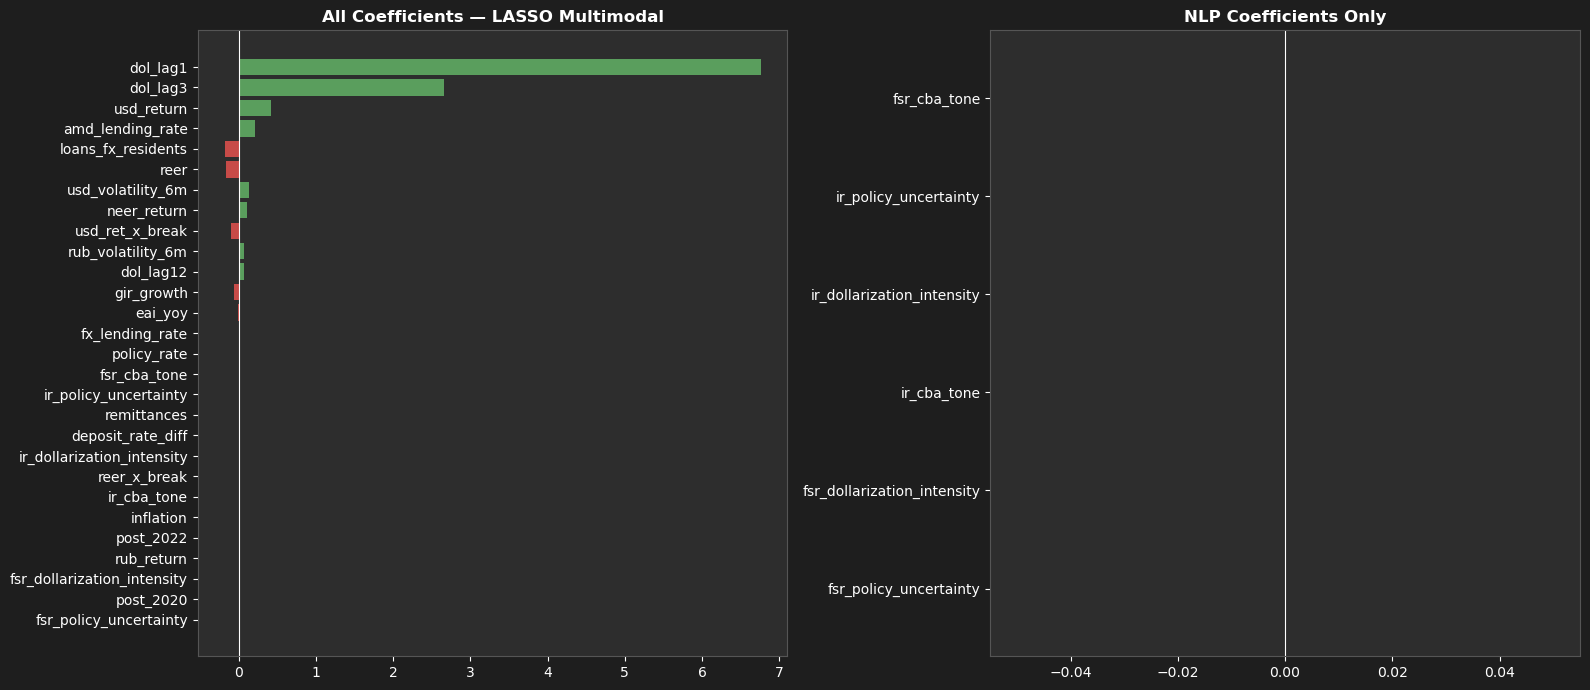

In [74]:
# ── 11. NLP FEATURE IMPORTANCE ────────────────────────────────────────────────
# Fit full-sample LASSO on multimodal matrix to get coefficients
binary_cols = [v for v in LASSO_VARS_MM if 'post_' in v]
scale_cols  = [v for v in LASSO_VARS_MM if v not in binary_cols]
scale_idx   = [LASSO_VARS_MM.index(v) for v in scale_cols]

scaler_full  = StandardScaler()
X_mm_scaled  = X_mm.copy().astype(float)
X_mm_scaled[:, scale_idx] = scaler_full.fit_transform(X_mm[:, scale_idx])

lasso_full = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_full.fit(X_mm_scaled, y_mm)

coef_df = pd.DataFrame({
    'Variable':    LASSO_VARS_MM,
    'Coefficient': lasso_full.coef_,
    'Is_NLP':      [v in all_nlp for v in LASSO_VARS_MM]
}).sort_values('Coefficient', key=abs, ascending=True)

nlp_coef = coef_df[coef_df['Is_NLP']]
print('=== NLP Feature Coefficients (full-sample LASSO) ===')
print(f'α = {lasso_full.alpha_:.5f}')
print()
print(nlp_coef[['Variable','Coefficient']].to_string(index=False))
print()
n_nlp_selected = (nlp_coef['Coefficient'] != 0).sum()
print(f'NLP features selected (non-zero): {n_nlp_selected} / {len(all_nlp)}')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# All coefficients
colors = ['#ef5350' if c < 0 else '#66bb6a' for c in coef_df['Coefficient']]
markers = ['^' if nlp else 'o' for nlp in coef_df['Is_NLP']]
ax1.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, alpha=0.8)
ax1.axvline(0, color='white', linewidth=0.8)
ax1.set_title('All Coefficients — LASSO Multimodal', fontweight='bold')
for i, (_, row) in enumerate(coef_df.iterrows()):
    if row['Is_NLP'] and row['Coefficient'] != 0:
        ax1.barh(row['Variable'], row['Coefficient'],
                 color='#ffd54f', alpha=1.0, label='NLP' if i == 0 else '')

# NLP only
nlp_colors = ['#ef5350' if c < 0 else '#66bb6a' for c in nlp_coef['Coefficient']]
ax2.barh(nlp_coef['Variable'], nlp_coef['Coefficient'], color=nlp_colors, alpha=0.9)
ax2.axvline(0, color='white', linewidth=0.8)
ax2.set_title('NLP Coefficients Only', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'multimodal_lasso_coefficients.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Sub-Period Analysis: Pre/Post 2022

Tests whether NLP features are more valuable in the post-2022 period when the AMD appreciation shock created a structural break and forward-looking CBA communication may have been more informative.

In [75]:
# ── 12. SUB-PERIOD ANALYSIS ───────────────────────────────────────────────────
dates_mm  = df_mm['Date'].values
break_dt  = np.datetime64('2022-03-01')

sub_rows = []
for model_name, s_preds, mm_preds in [
    ('LASSO',       lasso_s_aligned, lasso_mm_preds),
    ('Elastic Net', enet_s_aligned,  enet_mm_preds),
]:
    for period, pmask in [('Pre-2022',  dates_mm <  break_dt),
                           ('Post-2022', dates_mm >= break_dt)]:
        for label, preds in [('Structured', s_preds), ('Multimodal', mm_preds)]:
            m = ~np.isnan(preds) & pmask
            if m.sum() < 3:
                continue
            rmse = np.sqrt(mean_squared_error(y_compare[m], preds[m]))
            mae  = mean_absolute_error(y_compare[m], preds[m])
            sub_rows.append({
                'Model':   model_name,
                'Version': label,
                'Period':  period,
                'N':       m.sum(),
                'RMSE':    round(rmse, 4),
                'MAE':     round(mae, 4)
            })

sub_df = pd.DataFrame(sub_rows)

print('=== SUB-PERIOD ANALYSIS: Structured vs Multimodal ===')
print('Does NLP help more in the post-2022 period?\n')

for model_name in ['LASSO', 'Elastic Net']:
    print(f'  {model_name}:')
    m_df = sub_df[sub_df['Model'] == model_name]
    for period in ['Pre-2022', 'Post-2022']:
        p_df = m_df[m_df['Period'] == period]
        s_rmse  = p_df[p_df['Version']=='Structured']['RMSE'].values
        mm_rmse = p_df[p_df['Version']=='Multimodal']['RMSE'].values
        if len(s_rmse) and len(mm_rmse):
            delta = mm_rmse[0] - s_rmse[0]
            sign  = '✅' if delta < 0 else '⚠️'
            print(f'    {period}: Structured={s_rmse[0]:.4f}  Multimodal={mm_rmse[0]:.4f}  '
                  f'Δ={delta:+.4f} {sign}')
    print()

display(sub_df.pivot_table(index=['Model','Version'],
                            columns='Period',
                            values='RMSE').round(4))

=== SUB-PERIOD ANALYSIS: Structured vs Multimodal ===
Does NLP help more in the post-2022 period?

  LASSO:
    Pre-2022: Structured=1.2982  Multimodal=1.1162  Δ=-0.1820 ✅
    Post-2022: Structured=0.8329  Multimodal=0.8575  Δ=+0.0246 ⚠️

  Elastic Net:
    Pre-2022: Structured=1.3685  Multimodal=1.2337  Δ=-0.1348 ✅
    Post-2022: Structured=0.8134  Multimodal=0.8173  Δ=+0.0039 ⚠️



Period                  Post-2022  Pre-2022
Model       Version                        
Elastic Net Multimodal     0.8173    1.2337
            Structured     0.8134    1.3685
LASSO       Multimodal     0.8575    1.1162
            Structured     0.8329    1.2982

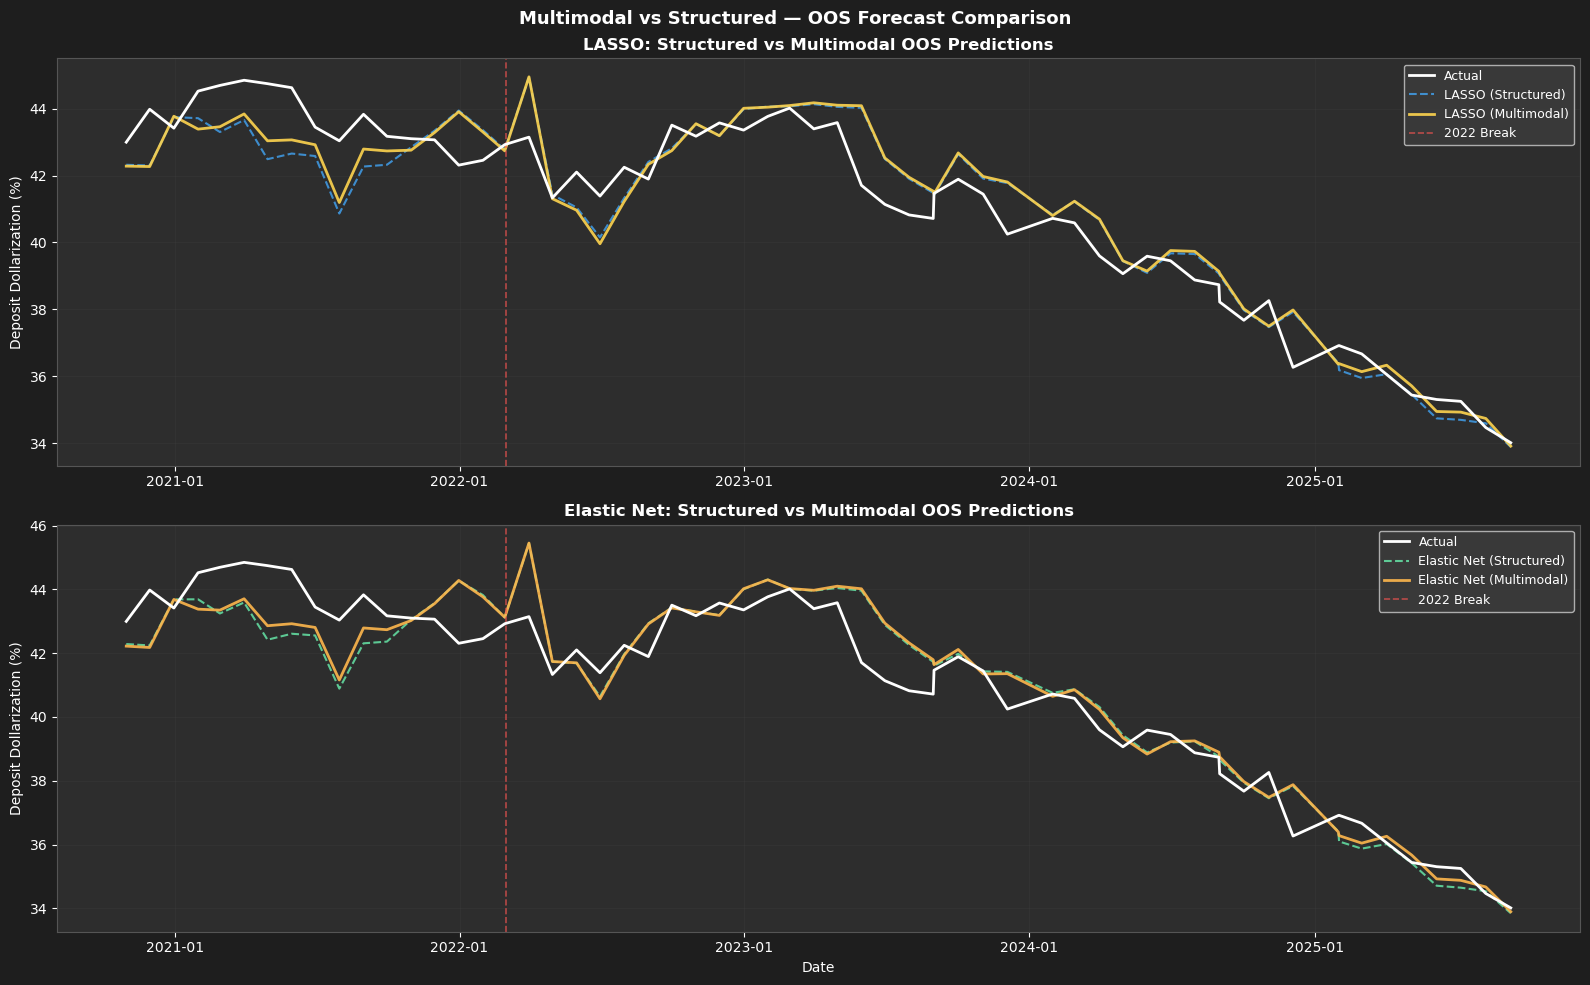

In [76]:
# ── 13. FORECAST COMPARISON PLOT ─────────────────────────────────────────────
dates_mm = df_mm['Date'].values
oos_mask = ~np.isnan(lasso_mm_preds)
oos_start = dates_mm[oos_mask][0]
oos_mask_plot = dates_mm >= oos_start

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, (model_name, s_p, mm_p, s_color, mm_color) in zip(axes, [
    ('LASSO',       lasso_s_aligned, lasso_mm_preds, '#42a5f5', '#ffd54f'),
    ('Elastic Net', enet_s_aligned,  enet_mm_preds,  '#69f0ae', '#ffb74d'),
]):
    ax.plot(dates_mm[oos_mask_plot], y_compare[oos_mask_plot],
            color='white', linewidth=2, label='Actual', zorder=5)

    s_m  = ~np.isnan(s_p)  & oos_mask_plot
    mm_m = ~np.isnan(mm_p) & oos_mask_plot

    ax.plot(dates_mm[s_m],  s_p[s_m],  color=s_color,  linewidth=1.5,
            linestyle='--', alpha=0.8, label=f'{model_name} (Structured)')
    ax.plot(dates_mm[mm_m], mm_p[mm_m], color=mm_color, linewidth=2.0,
            linestyle='-',  alpha=0.9, label=f'{model_name} (Multimodal)')

    ax.axvline(np.datetime64('2022-03-01'), color='#ef5350',
               linewidth=1.2, linestyle='--', alpha=0.7, label='2022 Break')
    ax.set_title(f'{model_name}: Structured vs Multimodal OOS Predictions',
                 fontweight='bold')
    ax.set_ylabel('Deposit Dollarization (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[-1].set_xlabel('Date')
plt.suptitle('Multimodal vs Structured — OOS Forecast Comparison',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'multimodal_forecast_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [77]:
# ── 14. SAVE ALL RESULTS ──────────────────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'multimodal_results.xlsx')

with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    comparison_mm.to_excel(writer, sheet_name='Structured_vs_Multimodal', index=False)
    dm_nlp_df.to_excel(writer,     sheet_name='DM_NLP_Contribution',       index=False)
    sub_df.to_excel(writer,        sheet_name='SubPeriod_Analysis',         index=False)
    coef_df.to_excel(writer,       sheet_name='LASSO_MM_Coefficients',      index=False)
    lasso_s_cv.to_excel(writer,    sheet_name='LASSO_S_CV')
    lasso_mm_cv.to_excel(writer,   sheet_name='LASSO_MM_CV')
    enet_s_cv.to_excel(writer,     sheet_name='ENet_S_CV')
    enet_mm_cv.to_excel(writer,    sheet_name='ENet_MM_CV')

    pred_df = pd.DataFrame({
        'Date':                    dates_mm,
        TARGET:                    y_compare,
        'LASSO_Structured':        lasso_s_aligned,
        'LASSO_Multimodal':        lasso_mm_preds,
        'ElasticNet_Structured':   enet_s_aligned,
        'ElasticNet_Multimodal':   enet_mm_preds,
    })
    pred_df.to_excel(writer, sheet_name='All_Predictions', index=False)

print(f'✅ Saved: {out_path}')

# Final summary
print()
print('=' * 65)
print('MULTIMODAL RESULTS SUMMARY')
print('=' * 65)
for _, row in comparison_mm.iterrows():
    print(f"  {row['Model']:<35} RMSE={row['RMSE']:.4f}  Dir={row['Dir. Accuracy (%)']:.1f}%")
print()
print('DM Test — NLP Contribution:')
for _, row in dm_nlp_df.iterrows():
    print(f"  {row['Model']:<15} p={row['p-value']}  {row['Result']}")
print('=' * 65)

✅ Saved: C:\Users\HP\Zvarth Aleksanyan\Data Science for Business\Thesis_Dolarization\Analysis\Outputs\multimodal_results.xlsx

MULTIMODAL RESULTS SUMMARY
  LASSO (Structured)                  RMSE=0.9873  Dir=52.5%
  LASSO (Multimodal)                  RMSE=0.9381  Dir=57.6%
  Elastic Net (Structured)            RMSE=1.0024  Dir=55.9%
  Elastic Net (Multimodal)            RMSE=0.9539  Dir=54.2%

DM Test — NLP Contribution:
  LASSO           p=0.2111  — No significant difference (p≥0.10)
  Elastic Net     p=0.1336  — No significant difference (p≥0.10)
